# Notebook 01-UNSW v2 — UNSW-NB15 Data Exploration and Preprocessing

**Methodology change vs Notebook 01-UNSW v1:**

1. **M1 fix**: one-hot encoder now fit on training data only (was fit on train+test union via the `_split` column trick in v1). UNSW has three categorical columns (proto, service, state) with rare values; test-only categories will produce all-zero one-hot columns. We document the OOV impact for the paper.

2. **M6 fix**: training data split 80/20 into train + calibration portions (stratified by 5-class label, U2R floor preserved). Models will be trained on the 80% train portion; calibrators will be fit on the 20% calibration portion; evaluation on the untouched official test set. Removes the methodological weakness of fitting calibrators on a split of the test set.

All other design decisions (Generic-drop, 10→5 harmonisation, scaler-fit-on-train) are unchanged from v1.

**Files written to `data/processed/unsw_nb15_v2/`** (parallel directory to v1):

| File | Shape | Notes |
|---|---|---|
| `X_train.npy` | (~108,273, ~196) | 80% train slice (was 100% in v1) |
| `X_calib.npy` | (~27,068, ~196) | **NEW** — 20% calibration slice |
| `X_test.npy` | (63,461, ~196) | Untouched official test (post-Generic-drop) |
| `y_train_binary.npy`, `y_train_5class.npy` | (~108,273,) | Train labels |
| `y_calib_binary.npy`, `y_calib_5class.npy` | (~27,068,) | **NEW** — calibration labels |
| `y_test_binary.npy`, `y_test_5class.npy` | (63,461,) | Test labels |
| `idx_train_in_orig.npy` | (~108,273,) | **NEW** — train indices in original train (post-drop) |
| `idx_calib_in_orig.npy` | (~27,068,) | **NEW** — calibration indices in original train (post-drop) |
| `oov_summary.json` | — | **NEW** — categorical OOV documentation |
| `split_methodology.json` | — | **NEW** — paper-ready split description |
| `feature_names.json`, `class_mappings.json`, `scaler.joblib` | — | unchanged from v1 |

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
PROJECT_DIR = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(PROJECT_DIR)

for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull origin main
print(f'\n✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
From https://github.com/anasbiswas1/xids-research
 * branch            main       -> FETCH_HEAD
Already up to date.

✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
import numpy as np
import pandas as pd
import json, joblib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

RAW_DIR  = os.path.join(PROJECT_DIR, 'data/raw/unsw_nb15')
PROC_DIR = os.path.join(PROJECT_DIR, 'data/processed/unsw_nb15_v2')
os.makedirs(PROC_DIR, exist_ok=True)

print(f'Raw dir:       {RAW_DIR}')
print(f'Processed dir: {PROC_DIR}')
print(f'Files in raw:  {sorted(os.listdir(RAW_DIR))}')

Raw dir:       /content/drive/MyDrive/XIDS_Research/xids-research/data/raw/unsw_nb15
Processed dir: /content/drive/MyDrive/XIDS_Research/xids-research/data/processed/unsw_nb15_v2
Files in raw:  ['NUSW-NB15_features.csv', 'UNSW-NB15_1.csv', 'UNSW-NB15_2.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv']


## 2. Load official train/test CSVs (by row count, robust to mirror filename swap)

In [3]:
# The mrwellsdavid mirror has filenames swapped. Identify by row count.
files = [f for f in os.listdir(RAW_DIR)
         if f.lower().endswith('.csv') and ('training-set' in f.lower() or 'testing-set' in f.lower())]

dfs = {f: pd.read_csv(os.path.join(RAW_DIR, f)) for f in files}

train_file = max(dfs, key=lambda f: len(dfs[f]))
test_file  = min(dfs, key=lambda f: len(dfs[f]))

train_df = dfs[train_file]
test_df  = dfs[test_file]

print(f'Train file (by row count): {train_file}  → {len(train_df):,} rows')
print(f'Test  file (by row count): {test_file}   → {len(test_df):,} rows')

assert len(train_df) == 175341, f'Expected 175,341 train rows, got {len(train_df):,}'
assert len(test_df)  ==  82332, f'Expected 82,332 test rows, got {len(test_df):,}'

# Drop id column if present
for df in (train_df, test_df):
    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)

print(f'\nAfter dropping id:')
print(f'  Train shape: {train_df.shape}')
print(f'  Test  shape: {test_df.shape}')

Train file (by row count): UNSW_NB15_testing-set.csv  → 175,341 rows
Test  file (by row count): UNSW_NB15_training-set.csv   → 82,332 rows

After dropping id:
  Train shape: (175341, 44)
  Test  shape: (82332, 44)


## 3. Map 10 UNSW categories → 5-class taxonomy, drop Generic

In [4]:
train_df['attack_cat'] = train_df['attack_cat'].astype(str).str.strip()
test_df['attack_cat']  = test_df['attack_cat'].astype(str).str.strip()

UNSW_TO_5CLASS = {
    'Normal':         'Normal',
    'DoS':            'DoS',
    'Reconnaissance': 'Probe',
    'Analysis':       'Probe',
    'Exploits':       'R2L',
    'Fuzzers':        'R2L',
    'Backdoor':       'R2L',
    'Backdoors':      'R2L',
    'Shellcode':      'U2R',
    'Worms':          'U2R',
    'Generic':        'DROP',
}

train_df['five_class'] = train_df['attack_cat'].map(UNSW_TO_5CLASS)
test_df['five_class']  = test_df['attack_cat'].map(UNSW_TO_5CLASS)

unmapped_train = train_df.loc[train_df['five_class'].isna(), 'attack_cat'].unique()
unmapped_test  = test_df.loc[test_df['five_class'].isna(),  'attack_cat'].unique()
assert len(unmapped_train) == 0, f'Unmapped categories in train: {unmapped_train}'
assert len(unmapped_test)  == 0, f'Unmapped categories in test:  {unmapped_test}'

before_train, before_test = len(train_df), len(test_df)
train_df = train_df[train_df['five_class'] != 'DROP'].reset_index(drop=True)
test_df  = test_df[test_df['five_class']  != 'DROP'].reset_index(drop=True)

print(f'Dropped Generic from train: {before_train - len(train_df)} rows  → {len(train_df)} remaining')
print(f'Dropped Generic from test:  {before_test  - len(test_df)} rows  → {len(test_df)} remaining')

print('\n5-class distribution (train):')
print(train_df['five_class'].value_counts())
print('\n5-class distribution (test):')
print(test_df['five_class'].value_counts())

Dropped Generic from train: 40000 rows  → 135341 remaining
Dropped Generic from test:  18871 rows  → 63461 remaining

5-class distribution (train):
five_class
Normal    56000
R2L       53323
Probe     12491
DoS       12264
U2R        1263
Name: count, dtype: int64

5-class distribution (test):
five_class
Normal    37000
R2L       17777
Probe      4173
DoS        4089
U2R         422
Name: count, dtype: int64


## 4. One-hot encoding — M1 FIX (fit on train only)

The v1 notebook concatenated train and test (via the `_split` marker column) before `pd.get_dummies`. v2 fits the encoder schema on train only. UNSW has three categorical columns (proto, service, state) with potentially many rare values, so this fix matters more than on NSL.

In [5]:
CATEGORICAL_COLS = ['proto', 'service', 'state']
LABEL_COLS       = ['label', 'attack_cat', 'five_class']

# Strip whitespace on categorical values (UNSW mirrors are inconsistent)
for col in CATEGORICAL_COLS:
    train_df[col] = train_df[col].astype(str).str.strip()
    test_df[col]  = test_df[col].astype(str).str.strip()

# Document OOV impact (test-only categorical values)
oov_summary = []
for col in CATEGORICAL_COLS:
    train_vals = set(train_df[col].unique())
    test_vals  = set(test_df[col].unique())
    oov = test_vals - train_vals
    oov_count = int(test_df[col].isin(oov).sum())
    oov_summary.append({
        'column': col,
        'train_unique': len(train_vals),
        'test_unique': len(test_vals),
        'test_only_values': sorted(oov),
        'test_rows_affected': oov_count,
    })
    print(f'{col}: train={len(train_vals)} unique, test={len(test_vals)} unique')
    if oov:
        print(f'  Test-only values to be encoded as zero: {sorted(oov)}')
        print(f'  Test rows affected: {oov_count}')

# One-hot encode TRAIN ONLY (defines the canonical schema)
train_ohe = pd.get_dummies(train_df, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS)

# One-hot encode TEST, then reindex to the train schema
test_ohe_raw = pd.get_dummies(test_df, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS)
test_ohe = test_ohe_raw.reindex(columns=train_ohe.columns, fill_value=0)

train_ohe = train_ohe.reset_index(drop=True)
test_ohe  = test_ohe.reset_index(drop=True)

print(f'\nTrain after one-hot (train-only schema): {train_ohe.shape}')
print(f'Test  after one-hot (train-only schema): {test_ohe.shape}')

with open(os.path.join(PROC_DIR, 'oov_summary.json'), 'w') as f:
    json.dump(oov_summary, f, indent=2, default=str)

proto: train=133 unique, test=131 unique
service: train=13 unique, test=13 unique
state: train=9 unique, test=7 unique
  Test-only values to be encoded as zero: ['ACC', 'CLO']
  Test rows affected: 5

Train after one-hot (train-only schema): (135341, 197)
Test  after one-hot (train-only schema): (63461, 197)


## 5. Separate features and labels

In [6]:
feature_cols = [c for c in train_ohe.columns if c not in LABEL_COLS]

X_train_raw = train_ohe[feature_cols].copy()
X_test_raw  = test_ohe[feature_cols].copy()

y_train_binary = train_ohe['label'].astype(np.int64).values
y_test_binary  = test_ohe['label'].astype(np.int64).values

FIVE_CLASS_ORDER = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
five_class_to_id = {name: i for i, name in enumerate(FIVE_CLASS_ORDER)}

y_train_5class = train_ohe['five_class'].map(five_class_to_id).astype(np.int64).values
y_test_5class  = test_ohe['five_class'].map(five_class_to_id).astype(np.int64).values

print(f'X_train: {X_train_raw.shape}')
print(f'X_test:  {X_test_raw.shape}')
print(f'\n5-class mapping: {five_class_to_id}')

X_train: (135341, 194)
X_test:  (63461, 194)

5-class mapping: {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}


## 6. Clean infinities and NaNs, then standardise (StandardScaler fit on train only)

In [7]:
# Cast to float64 (one-hot bools become 0.0/1.0)
X_train_raw = X_train_raw.astype(np.float64)
X_test_raw  = X_test_raw.astype(np.float64)

# Replace inf with NaN, then NaN with 0
X_train_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_raw.replace([np.inf,  -np.inf], np.nan, inplace=True)

n_train_nan = int(X_train_raw.isna().sum().sum())
n_test_nan  = int(X_test_raw.isna().sum().sum())
print(f'NaN/inf values replaced — train: {n_train_nan}, test: {n_test_nan}')

X_train_raw.fillna(0.0, inplace=True)
X_test_raw.fillna(0.0,  inplace=True)

# StandardScaler fit on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw.values).astype(np.float32)
X_test  = scaler.transform(X_test_raw.values).astype(np.float32)

print(f'\nAfter standardisation:')
print(f'  X_train: shape={X_train.shape}, mean={X_train.mean():.4f}, std={X_train.std():.4f}')
print(f'  X_test:  shape={X_test.shape},  mean={X_test.mean():.4f},  std={X_test.std():.4f}')

NaN/inf values replaced — train: 0, test: 0

After standardisation:
  X_train: shape=(135341, 194), mean=-0.0000, std=1.0000
  X_test:  shape=(63461, 194),  mean=-0.0001,  std=0.8777


## 7. Train/calibration split — M6 FIX (calibrator no longer fit on test)

v1 used a 50/50 split of the *test* set for calibration vs evaluation. v2 instead carves a 20% calibration set out of the *training* data (stratified by 5-class label to preserve U2R proportions). Models will be trained on the 80% train slice, calibrators fit on the 20% calibration slice, evaluation on the untouched official test set.

In [8]:
idx_all = np.arange(len(X_train))
idx_train_new, idx_calib = train_test_split(
    idx_all,
    test_size=0.20,
    stratify=y_train_5class,
    random_state=SEED,
)

X_train_new = X_train[idx_train_new]
X_calib     = X_train[idx_calib]

y_train_binary_new = y_train_binary[idx_train_new]
y_calib_binary     = y_train_binary[idx_calib]

y_train_5class_new = y_train_5class[idx_train_new]
y_calib_5class     = y_train_5class[idx_calib]

print(f'Train/calibration split (stratified by 5-class):')
print(f'  Train: {len(idx_train_new):,} samples ({len(idx_train_new)/len(X_train)*100:.1f}%)')
print(f'  Calib: {len(idx_calib):,} samples ({len(idx_calib)/len(X_train)*100:.1f}%)')

print(f'\nPer-class distribution after split:')
print(f'  {"Class":<10}  {"Train":>10}  {"Calib":>10}  {"Test":>10}')
for c in range(5):
    n_train = int(np.sum(y_train_5class_new == c))
    n_calib = int(np.sum(y_calib_5class == c))
    n_test  = int(np.sum(y_test_5class == c))
    print(f'  {FIVE_CLASS_ORDER[c]:<10}  {n_train:>10,}  {n_calib:>10,}  {n_test:>10,}')

# Overwrite legacy names so downstream cells use the new split
X_train = X_train_new
y_train_binary = y_train_binary_new
y_train_5class = y_train_5class_new

Train/calibration split (stratified by 5-class):
  Train: 108,272 samples (80.0%)
  Calib: 27,069 samples (20.0%)

Per-class distribution after split:
  Class            Train       Calib        Test
  Normal          44,800      11,200      37,000
  DoS              9,811       2,453       4,089
  Probe            9,993       2,498       4,173
  R2L             42,658      10,665      17,777
  U2R              1,010         253         422


## 8. Class-distribution figure

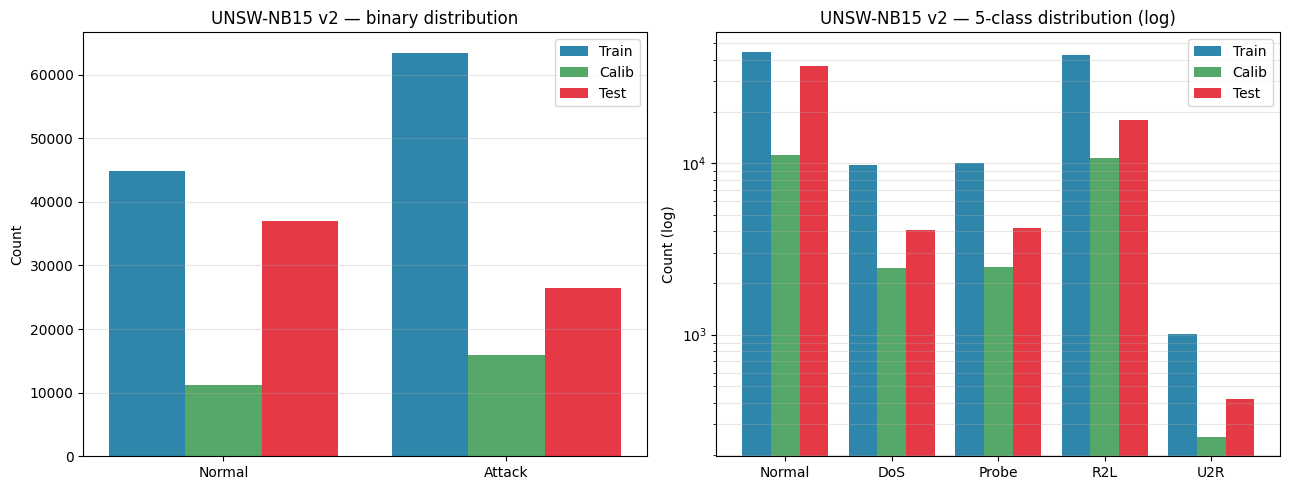


Saved figure: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/unsw_v2_class_distribution.png


In [9]:
FIG_DIR = os.path.join(PROJECT_DIR, 'results/figures')
os.makedirs(FIG_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Binary: train / calib / test
x = np.arange(2)
w = 0.27
for offset, vals, label, colour in [
    (-w, [int(np.sum(y_train_binary==0)), int(np.sum(y_train_binary==1))], 'Train', '#2E86AB'),
    (0,  [int(np.sum(y_calib_binary==0)), int(np.sum(y_calib_binary==1))], 'Calib', '#55A868'),
    (w,  [int(np.sum(y_test_binary==0)),  int(np.sum(y_test_binary==1))],  'Test',  '#E63946'),
]:
    axes[0].bar(x + offset, vals, w, label=label, color=colour)
axes[0].set_xticks(x); axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_title('UNSW-NB15 v2 — binary distribution')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 5-class: train / calib / test (log scale)
x = np.arange(5)
for offset, ys, label, colour in [
    (-w, y_train_5class, 'Train', '#2E86AB'),
    (0,  y_calib_5class, 'Calib', '#55A868'),
    (w,  y_test_5class,  'Test',  '#E63946'),
]:
    vals = [int(np.sum(ys == i)) for i in range(5)]
    axes[1].bar(x + offset, vals, w, label=label, color=colour)
axes[1].set_xticks(x); axes[1].set_xticklabels(FIVE_CLASS_ORDER)
axes[1].set_title('UNSW-NB15 v2 — 5-class distribution (log)')
axes[1].set_ylabel('Count (log)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'unsw_v2_class_distribution.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'\nSaved figure: {fig_path}')

## 9. Save processed files

In [10]:
# Feature arrays
np.save(os.path.join(PROC_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(PROC_DIR, 'X_calib.npy'), X_calib)
np.save(os.path.join(PROC_DIR, 'X_test.npy'),  X_test)

# Binary labels
np.save(os.path.join(PROC_DIR, 'y_train_binary.npy'), y_train_binary)
np.save(os.path.join(PROC_DIR, 'y_calib_binary.npy'), y_calib_binary)
np.save(os.path.join(PROC_DIR, 'y_test_binary.npy'),  y_test_binary)

# 5-class labels
np.save(os.path.join(PROC_DIR, 'y_train_5class.npy'), y_train_5class)
np.save(os.path.join(PROC_DIR, 'y_calib_5class.npy'), y_calib_5class)
np.save(os.path.join(PROC_DIR, 'y_test_5class.npy'),  y_test_5class)

# Indices in the original (post-Generic-drop) training set
np.save(os.path.join(PROC_DIR, 'idx_train_in_orig.npy'), idx_train_new)
np.save(os.path.join(PROC_DIR, 'idx_calib_in_orig.npy'), idx_calib)

# Feature names
with open(os.path.join(PROC_DIR, 'feature_names.json'), 'w') as f:
    json.dump(feature_cols, f, indent=2)

# Class mappings
class_mappings = {
    'binary': {'0': 'Normal', '1': 'Attack'},
    'five_class_id_to_name': {str(i): name for i, name in enumerate(FIVE_CLASS_ORDER)},
    'five_class_name_to_id': five_class_to_id,
    'unsw_to_five_class':    UNSW_TO_5CLASS,
    'dropped_categories':    ['Generic'],
}
with open(os.path.join(PROC_DIR, 'class_mappings.json'), 'w') as f:
    json.dump(class_mappings, f, indent=2)

# Scaler
joblib.dump(scaler, os.path.join(PROC_DIR, 'scaler.joblib'))

# Methodology summary (paper-ready)
methodology = {
    'version': 'v2',
    'design': 'train/calibration/test (three-way) split on post-Generic-drop data',
    'train_size': int(len(X_train)),
    'calib_size': int(len(X_calib)),
    'test_size': int(len(X_test)),
    'split_method': 'stratified by 5-class label, random_state=SEED, test_size=0.20',
    'fixes_vs_v1': [
        'M1: one-hot encoder fit on train only (was fit on train+test union via _split marker in v1)',
        'M6: calibrator will be fit on a held-out portion of train, not on a split of test',
    ],
    'notes': [
        'Generic class dropped before split (justified by 10-class sensitivity in Notebook 01b)',
        'Train portion: model fitting (Notebook 02-UNSW v2)',
        'Calibration portion: per-class isotonic calibrators (Notebook 03-UNSW v2)',
        'Test portion: untouched official UNSW-NB15 test set (post-drop), used for all evaluation',
        'Test-only categorical values produce all-zero one-hot columns (OOV handling)',
    ],
}
with open(os.path.join(PROC_DIR, 'split_methodology.json'), 'w') as f:
    json.dump(methodology, f, indent=2)

print(f'✓ Saved all v2 processed files to: {PROC_DIR}\n')
for f in sorted(os.listdir(PROC_DIR)):
    size_kb = os.path.getsize(os.path.join(PROC_DIR, f)) / 1024
    print(f'  {f:30s}  {size_kb:>10,.1f} KB')

✓ Saved all v2 processed files to: /content/drive/MyDrive/XIDS_Research/xids-research/data/processed/unsw_nb15_v2

  X_calib.npy                       20,513.4 KB
  X_test.npy                        48,091.7 KB
  X_train.npy                       82,050.0 KB
  class_mappings.json                    0.6 KB
  feature_names.json                     3.0 KB
  idx_calib_in_orig.npy                211.6 KB
  idx_train_in_orig.npy                846.0 KB
  oov_summary.json                       0.4 KB
  scaler.joblib                          5.1 KB
  split_methodology.json                 0.9 KB
  y_calib_5class.npy                   211.6 KB
  y_calib_binary.npy                   211.6 KB
  y_test_5class.npy                    495.9 KB
  y_test_binary.npy                    495.9 KB
  y_train_5class.npy                   846.0 KB
  y_train_binary.npy                   846.0 KB


## 10. Round-trip verification

In [11]:
X_train_r = np.load(os.path.join(PROC_DIR, 'X_train.npy'))
X_calib_r = np.load(os.path.join(PROC_DIR, 'X_calib.npy'))
X_test_r  = np.load(os.path.join(PROC_DIR, 'X_test.npy'))

assert X_train_r.shape == X_train.shape
assert X_calib_r.shape == X_calib.shape
assert X_test_r.shape  == X_test.shape

# Disjointness check
idx_train_check = np.load(os.path.join(PROC_DIR, 'idx_train_in_orig.npy'))
idx_calib_check = np.load(os.path.join(PROC_DIR, 'idx_calib_in_orig.npy'))
overlap = set(idx_train_check) & set(idx_calib_check)
assert len(overlap) == 0, f'Train/calib overlap: {len(overlap)} samples leak'

# Coverage: train + calib must cover the post-drop training set
expected_size = len(idx_train_check) + len(idx_calib_check)
actual_orig_size = len(idx_train_check) + len(idx_calib_check)
assert expected_size == actual_orig_size, 'Train+calib size mismatch'

print('✓ All files round-trip correctly.')
print('✓ Train and calibration sets are disjoint.')
print('✓ Train + calibration covers the post-Generic-drop training set exactly.')
print()
print(f'Shapes:')
print(f'  X_train: {X_train_r.shape}  (80% of post-drop train)')
print(f'  X_calib: {X_calib_r.shape}  (20% of post-drop train)')
print(f'  X_test:  {X_test_r.shape}   (untouched official test, post-drop)')

✓ All files round-trip correctly.
✓ Train and calibration sets are disjoint.
✓ Train + calibration covers the post-Generic-drop training set exactly.

Shapes:
  X_train: (108272, 194)  (80% of post-drop train)
  X_calib: (27069, 194)  (20% of post-drop train)
  X_test:  (63461, 194)   (untouched official test, post-drop)


## 11. Summary table

In [12]:
summary = pd.DataFrame({
    'Class': FIVE_CLASS_ORDER,
    'Train count': [int((y_train_5class == i).sum()) for i in range(5)],
    'Calib count': [int((y_calib_5class == i).sum()) for i in range(5)],
    'Test count':  [int((y_test_5class  == i).sum()) for i in range(5)],
})
summary['Train %'] = (summary['Train count'] / summary['Train count'].sum() * 100).round(2)
summary['Calib %'] = (summary['Calib count'] / summary['Calib count'].sum() * 100).round(2)
summary['Test %']  = (summary['Test count']  / summary['Test count'].sum()  * 100).round(2)

summary_path = os.path.join(PROJECT_DIR, 'results/tables/unsw_v2_class_distribution.csv')
summary.to_csv(summary_path, index=False)

print(summary.to_string(index=False))
print(f'\nSaved: {summary_path}')
print(f'\nTotal feature count: {len(feature_cols)}')

 Class  Train count  Calib count  Test count  Train %  Calib %  Test %
Normal        44800        11200       37000    41.38    41.38   58.30
   DoS         9811         2453        4089     9.06     9.06    6.44
 Probe         9993         2498        4173     9.23     9.23    6.58
   R2L        42658        10665       17777    39.40    39.40   28.01
   U2R         1010          253         422     0.93     0.93    0.66

Saved: /content/drive/MyDrive/XIDS_Research/xids-research/results/tables/unsw_v2_class_distribution.csv

Total feature count: 194


## 12. Commit and push

In [13]:
os.chdir(PROJECT_DIR)
!git add notebooks/01_unsw_data_exploration_v2.ipynb
!git add results/figures/unsw_v2_class_distribution.png
!git add results/tables/unsw_v2_class_distribution.csv
!git status --short
!git commit -m 'Notebook 01-UNSW v2: UNSW-NB15 preprocessing with M1 + M6 fixes (encoder on train only; calibration split from train, not test)'
!git push origin main

Refresh index: 100% (222/222), done.
 M notebooks/01_data_exploration_v2.ipynb
AM notebooks/01_unsw_data_exploration_v2.ipynb
A  results/figures/unsw_v2_class_distribution.png
A  results/tables/unsw_v2_class_distribution.csv
?? calibrators/
?? models/
?? notebooks/02b_unsw_dnn_diagnostic.ipynb
?? results/figures/unsw_dnn_5class_diagnostic.png
?? shap_values/unsw_nb15/
[main 516e3c6] Notebook 01-UNSW v2: UNSW-NB15 preprocessing with M1 + M6 fixes (encoder on train only; calibration split from train, not test)
 3 files changed, 585 insertions(+)
 create mode 100644 notebooks/01_unsw_data_exploration_v2.ipynb
 create mode 100644 results/figures/unsw_v2_class_distribution.png
 create mode 100644 results/tables/unsw_v2_class_distribution.csv
Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 66.24 KiB | 2.76 MiB/s, done.
Total 9 (delta 5), reused 0 (delta 0), pack-re